In [12]:
import numpy as np
from scipy import stats
import math as math
import matplotlib.pyplot as plt
import time
from datetime import datetime
import matplotlib.pyplot as plt
import random

In [13]:
def filein(fname):
    numlines = 0
    xin = []
    f = open(fname, 'r')
    for line in f:
        # print (line, end='')
        xin.append(line)
        numlines = numlines+1
    f.close()
    return xin, numlines
    data, numlines = filein(fname)
    # print ('\ndata\n',data,'\nlines',numlines)
    x = ['0' for i in range(numlines)]
    for i in range(numlines):
        x[i] = data[i].replace('\n', '')
        x[i] = eval(x[i])
    return x, numlines


In [14]:
# reads any text table with n columns
# elements in a row separated by a TAB
# rows separated by a RETURN


def getxn(fname):
    data, numlines = filein(fname)
    dataline = ['0' for i in range(numlines)]
    for i in range(numlines):
        x = data[i]
        y = x.split('\t')
        y[-1] = y[-1].replace('\n', '')
        dataline[i] = y
    # print ('\n\nascii-input',dataline)
    xdata = dataline[:]
    for i in range(numlines):
        inline = len(dataline[i])
        for j in range(inline):
            if xdata[i][j] != '':
                xdata[i][j] = eval(xdata[i][j])
            else:
                xdata[i][j] = None
    # print ('dataline',dataline)
    # print ('xdata',xdata)
    return xdata, numlines

In [15]:

def binary_summary_report(arr):
    """
    Takes a 2D binary array, sorts it, and prints a summary table.
    """
    nrows, ncols = arr.shape

    # 1. Convert to Decimal using Dot Product (Fastest)
    # Using 'object' dtype handles up to 100+ columns if necessary,
    # but for < 64 bits, standard int64 is used automatically.
    powers = 1 << np.arange(ncols)[::-1]
    decimal_values = arr.dot(powers)

    # 2. Get unique values and their frequencies
    unique_vals, counts = np.unique(decimal_values, return_counts=True)

    # 3. Reconstruct Binary Rows for display (Vectorized)
    # This creates a bitmask to turn decimals back into [1, 0, 1, 0] format
    unique_binary_rows = ((unique_vals[:, None] & (
        1 << np.arange(ncols)[::-1])) > 0).astype(int)

    # 4. Print the Summary Table
    header = f"{'Unique Decimal':<15} | {
        'Binary Equivalent':<25} | {'Count (Frequency)':<15}"
    print(header)
    print("-" * len(header))

    for i in range(len(unique_vals)):
        # Convert to list for cleaner printing
        bin_row = unique_binary_rows[i].tolist()
        print(f"{unique_vals[i]:<15} | {str(bin_row):<25} | {counts[i]:<15}")

    # Return the dictionary as requested previously
    return dict(zip(unique_vals, counts))

In [16]:
def draw_flexible_box_grid(n, label_list, datain, now):
    total_boxes = 2**n

    # 1. Determine Grid Dimensions (Width >= Height)
    width = 2**((n + 1) // 2)
    height = 2**(n // 2)

    # 2. Handle Custom Labels
    # Convert to list and pad with empty strings if the user provided too few
    full_labels = list(label_list)
    if len(full_labels) < total_boxes:
        full_labels += [""] * (total_boxes - len(full_labels))

    # Take only the amount needed for the grid
    display_labels = full_labels[:total_boxes]

    # 3. Reshape into the grid matrix
    grid_labels = np.array(display_labels).reshape(height, width)

    fig, ax = plt.subplots(figsize=(width * 1.5, height * 1.5))

    for i in range(height):
        for j in range(width):
            # Coordinates for top-down numbering
            rect = plt.Rectangle((j, height - i - 1), 1, 1,
                                 fill=False, edgecolor='black', linewidth=2)
            ax.add_patch(rect)

            # Place the custom label
            ax.text(j + 0.5, height - i - 0.5, grid_labels[i, j],
                    ha='center', va='center',
                    fontsize=12 if n < 5 else 9)

    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect('equal')
    ax.axis('off')
    # plt.title(f"Custom Grid: n={n} ({width}x{height})", pad=20)
    # newtitle = datain+'    '+f"total_boxes={total_boxes}"+ '    ' +now
    newtitle = programname+'    '+datain+'    '+f"boxes={total_boxes}"+\
        '    ' +titlenote+'    '+now
    plt.title(newtitle, pad=20)
    plt.show()

In [17]:
programname='hidim_14.py'
# inout data
# cols separated by TAB
# reos sepsarated by RETURN
# floatihng point numers [0,1]
inputname = input('\ninput file namem (e.g. data6.txt)')
titlenote=input('\ninput title note (e.g. noise=0.7)')
data, ndata = getxn(inputname)
print('\ndata= ', data)
adata = np.array(data)
print('\nadata.shape (row,col)', adata.shape)
[nrow, ncol] = adata.shape


input file namem (e.g. data6.txt) data12.txt

input title note (e.g. noise=0.7) 



data=  [[0.5, 0.5, 0.02, 0.36, 0.87, 0.05, 0.21, 0.99, 0.74, 0.85, 0.81, 0.24, 0.39, 0.63, 0.6, 0.18], [-0.5, -0.5, -0.62, -0.13, -0.55, -0.27, -0.08, -0.86, -0.37, -0.91, -0.36, -0.94, -0.65, -0.74, -0.81, -0.65], [0.5, 0.5, 0.47, 0.72, 0.8, 0.11, 0.37, 0.18, 0.27, 0.79, 0.68, 0.69, 0.5, 0.61, 0.79, 0.94], [-0.5, -0.5, -0.28, -0.31, -0.45, -0.01, -0.2, -0.24, -0.86, -0.76, -0.12, -0.27, -0.95, -0.23, -0.17, -0.13], [0.5, 0.5, 0.06, 0.96, 0.76, 0.12, 0.45, 0.74, 0.05, 0.82, 0.12, 0.91, 0.82, 0.43, 0.73, 0.27], [-0.5, -0.5, -0.69, -0.92, -0.89, -0.36, -0.58, -0.22, -0.36, -0.98, -0.56, -0.45, -0.5, -0.75, -0.55, -0.99], [0.5, 0.5, 0.99, 0.41, 0.19, 0.73, 0.63, 0.06, 0.45, 0.17, 0.85, 0.55, 0.78, 0.85, 0.65, 0.2], [-0.5, -0.5, -0.75, -0.89, -0.61, -0.82, -0.55, -0.13, -0.41, -0.2, -0.01, -0.68, -0.14, -0.92, -0.73, -0.03], [0.5, 0.5, 0.49, 0.58, 0.38, 0.22, 0.97, 0.67, 0.58, 0.61, 0.71, 0.62, 0.96, 0.59, 0.89, 0.41], [-0.5, -0.5, -0.41, -0.05, -0.9, -0.4, -0.82, -0.61, -0.25, -0.91, -0.

In [18]:
bdata = np.zeros((nrow, ncol), dtype=int)

# #make bdata[i,j] = 0 (if adata <= 0) = 1 (if adata > 0)
for irow in range(nrow):
    for icol in range(ncol):
        if adata[irow, icol] > 0.:
            bdata[irow, icol] = 1
print('\nbdata\n', bdata)


bdata
 [[1 1 1 ... 1 1 1]
 [0 0 0 ... 0 0 0]
 [1 1 1 ... 1 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [1 1 1 ... 1 1 1]
 [0 0 0 ... 0 0 0]]


In [19]:
# DO HAMMING DISTANCE COLS
target_0 = np.zeros((nrow), dtype=int)
target_1 = np.ones((nrow), dtype=int)
# for icol in range (ncol)
ham = np.zeros((ncol), dtype=int)
for icol in range(ncol):
    col_test = bdata[:, icol].copy()
    # print ('\ni, col_test= ',icol,col_test)
    ham_0 = np.sum(col_test != target_0)
    ham_1 = np.sum(col_test != target_1)
    ham[icol] = min(ham_0, ham_1)
    print('\ntarget_0, target_1, ham     ', ham_0, ham_1, ham[icol])


target_0, target_1, ham      110 110 110

target_0, target_1, ham      110 110 110

target_0, target_1, ham      110 110 110

target_0, target_1, ham      109 111 109

target_0, target_1, ham      108 112 108

target_0, target_1, ham      108 112 108

target_0, target_1, ham      110 110 110

target_0, target_1, ham      110 110 110

target_0, target_1, ham      110 110 110

target_0, target_1, ham      110 110 110

target_0, target_1, ham      109 111 109

target_0, target_1, ham      110 110 110

target_0, target_1, ham      109 111 109

target_0, target_1, ham      109 111 109

target_0, target_1, ham      110 110 110

target_0, target_1, ham      108 112 108


In [20]:
# first sort ham
# want the position in ham to be the min value
hamlow = np.zeros((ncol), dtype=int)
hamlow = np.argsort(ham)
cdata = bdata[:, hamlow]  # pretty fancy, thank you Gemini
print('\nbdata\n', bdata)
print('\ncdata\n', cdata)


bdata
 [[1 1 1 ... 1 1 1]
 [0 0 0 ... 0 0 0]
 [1 1 1 ... 1 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [1 1 1 ... 1 1 1]
 [0 0 0 ... 0 0 0]]

cdata
 [[1 1 1 ... 1 1 1]
 [0 0 0 ... 0 0 0]
 [1 1 1 ... 1 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [1 1 1 ... 1 1 1]
 [0 0 0 ... 0 0 0]]


Sorted Array:
 []

Unique Decimal Values: [0]
Frequency Counts:      [220]
Unique Decimal  | Binary Equivalent         | Count (Frequency)
---------------------------------------------------------------
0               | []                        | 220            


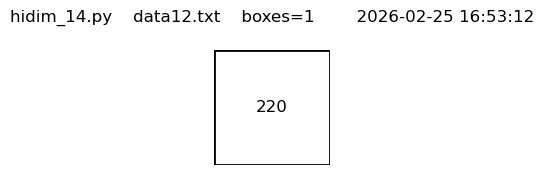

Sorted Array:
 [[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]


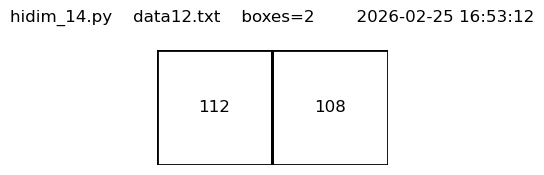

Sorted Array:
 [[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1

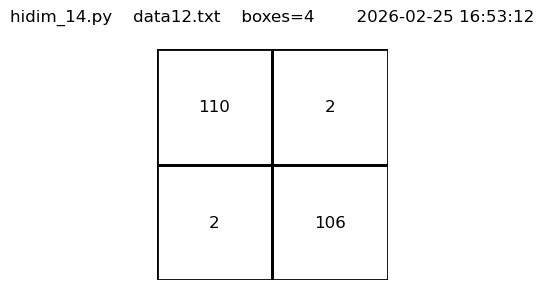

Sorted Array:
 [[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 

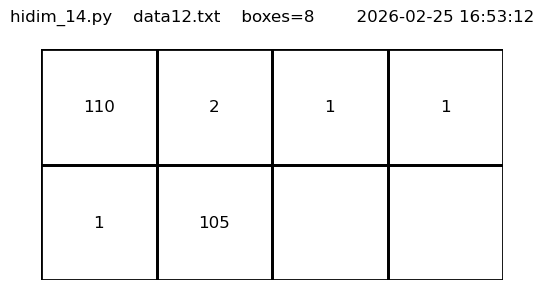

Sorted Array:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 

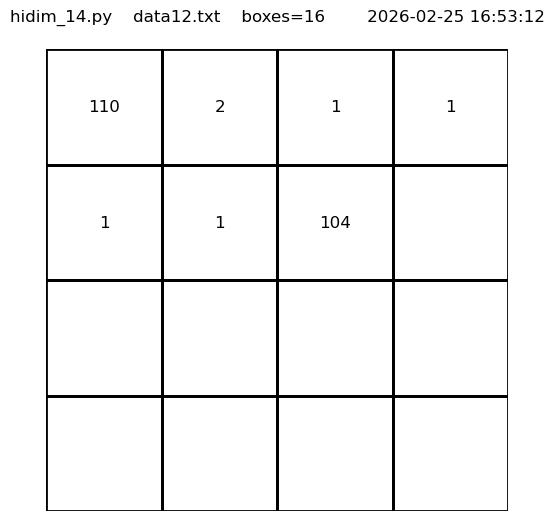

Sorted Array:
 [[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 ...
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]

Unique Decimal Values: [ 0 15 19 23 27 29 30 31]
Frequency Counts:      [110   2   1   1   1   1   1 103]
Unique Decimal  | Binary Equivalent         | Count (Frequency)
---------------------------------------------------------------
0               | [0, 0, 0, 0, 0]           | 110            
15              | [0, 1, 1, 1, 1]           | 2              
19              | [1, 0, 0, 1, 1]           | 1              
23              | [1, 0, 1, 1, 1]           | 1              
27              | [1, 1, 0, 1, 1]           | 1              
29              | [1, 1, 1, 0, 1]           | 1              
30              | [1, 1, 1, 1, 0]           | 1              
31              | [1, 1, 1, 1, 1]           | 103            


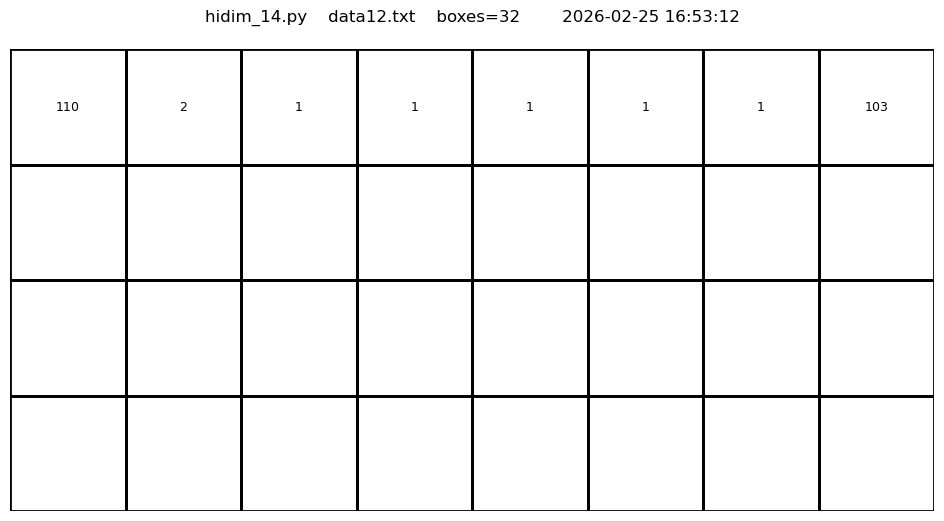

In [21]:
# OK that's ALL sorted, let's now do the BIGLOOP
# OK MESSED UP dont need to run SORT but do need COURNTS
now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
for bigloop in range(6):  # not doing anything yet
    n = 2**bigloop
    edata = cdata[:, 0:bigloop]
    mrow, mcol = edata.shape
    mpowers = 1 << np.arange(mcol)[::-1]
    mdecimal_values = edata.dot(mpowers)
    sorted_indices = np.argsort(mdecimal_values)
    sorted_e = edata[sorted_indices]
    munique_decimals, mcounts = np.unique(mdecimal_values, return_counts=True)
    # 5. Result Display
    print("Sorted Array:\n", sorted_e)
    print("\nUnique Decimal Values:", munique_decimals)
    print("Frequency Counts:     ", mcounts)
    results = binary_summary_report(edata)
# my_labels = ["Start", "A1", "B2", "C3", "D4", "E5", "F6", "End"]
    my_labels = mcounts.astype(str).tolist()
    draw_flexible_box_grid(bigloop, my_labels, inputname, now)